<a href="https://colab.research.google.com/github/alearecuest/anyoneai-exercises-sprint_3/blob/main/17_6_2_THEORY_LangChain_Q%26A_Over_Documents_(OpenAI).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain > /dev/null
!pip install chromadb > /dev/null
!pip install openai > /dev/null
!pip install tiktoken > /dev/null
!pip install langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.0 MB/s eta 0:00:00


# QA over Documents with LangChain

Here we walk through how to use LangChain for question answering over a document. Under the hood we'll be using [LangChain's Document chains](https://python.langchain.com/docs/modules/chains/document/).

We will be using [OpenAI's Embeddings](https://platform.openai.com/docs/guides/embeddings) and GPT, so let's set up our OpenAI API Key.

In [ ]:
import getpass

openai_api_key = getpass.getpass(prompt='Enter your OpenAI API Key: ')

Enter your OpenAI API Key: ··········


## Preparing the Data

Let's load our data using [LangChain](https://python.langchain.com/docs) and [ChromaDB](https://www.trychroma.com/), obtaining our text from [Chip Huyen's post about Infrastructure in Data Science](https://huyenchip.com/2021/09/13/data-science-infrastructure.html).

In [ ]:
from langchain.docstore.document import Document
from langchain.document_loaders import WebBaseLoader
from langchain.embeddings import OpenAIEmbeddings
from langchain.indexes.vectorstore import VectorstoreIndexCreator
from langchain.prompts import PromptTemplate
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.vectorstores import Chroma

loader = WebBaseLoader("https://huyenchip.com/2021/09/13/data-science-infrastructure.html")
data = loader.load()
data = data[0].page_content

In [ ]:
data

'\n\n\n\n\n\nWhy data scientists shouldn‚Äôt need to know Kubernetes\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nWhy data scientists shouldn‚Äôt need to know Kubernetes | Chip Huyen\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nChip Huyen\n\n\n\n\n\n\n\n\n\n\n\n\nBlog\nBooks\nEvents\n\nAI Guide\n\nAI Roadmap\nLlama Police\nML Interviews\n\n\nList 100\nVN\n\n\n\n\n\n\n\n\n\n\n\n\n\nTable of Contents\n\n- The full-stack expectations\n- Development vs. production environments\n- [Bridging the gap] Part I: containerization\n- [Bridging the gap] Part II: infrastructure abstraction\n\nWorkflow orchestration vs. infrastructure abstraction\nWorkflow orchestration: Airflow vs. Prefect vs. Argo\nInfrastructure abstraction: Kubeflow vs. Metaflow\n\n- Takeaways\n\n\n\n    Table of Contents \n\n\n\n\nWhy data scientists shouldn‚Äôt need to know Kubernetes\n\n\n        \n        Sep 13, 2021\n      \n      \n        ‚Ä¢ Chip Huyen\n\n\n\n[Hacker News discussion, Twitter thread]\nRecently, there have been many

Let's split our text in chunks, and obtain embeddings out of it.

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1248, chunk_overlap=0)
texts = text_splitter.split_text(data)
embeddings = OpenAIEmbeddings(openai_api_key=openai_api_key)

/tmp/ipython-input-8-2178514727.py:3: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embeddings = OpenAIEmbeddings(openai_api_key=openai_api_key)


In [ ]:
# Delete Chroma collection if there is one saved
Chroma().delete_collection()
docsearch = Chroma.from_texts(texts, embeddings, metadatas=[{"source": str(i)} for i in range(len(texts))]).as_retriever()

/tmp/ipython-input-9-4243964999.py:2: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  Chroma().delete_collection()


We can start answering questions with some more lines of code!

In [ ]:
from langchain.chains.question_answering import load_qa_chain
from langchain.llms import OpenAI
# Load the Language Model with temperature = 0
llm = OpenAI(temperature=0, openai_api_key=openai_api_key)


/tmp/ipython-input-10-2770910389.py:4: LangChainDeprecationWarning: The class `OpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAI``.
  llm = OpenAI(temperature=0, openai_api_key=openai_api_key)


In [ ]:
chain = load_qa_chain(llm, chain_type="stuff")
query = "Why did Chip Huyen become a data scientist?"
docs = docsearch.get_relevant_documents(query)
chain.run(input_documents=docs, question=query)

/tmp/ipython-input-11-2989907603.py:1: LangChainDeprecationWarning: This class is deprecated. See the following migration guides for replacements based on `chain_type`:
stuff: https://python.langchain.com/docs/versions/migrating_chains/stuff_docs_chain
map_reduce: https://python.langchain.com/docs/versions/migrating_chains/map_reduce_chain
refine: https://python.langchain.com/docs/versions/migrating_chains/refine_chain
map_rerank: https://python.langchain.com/docs/versions/migrating_chains/map_rerank_docs_chain

See also guides on retrieval and question-answering here: https://python.langchain.com/docs/how_to/#qa-with-rag
  chain = load_qa_chain(llm, chain_type="stuff")
/tmp/ipython-input-11-2989907603.py:3: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  docs = docsearch.get_relevant_documents(query)
/tmp/ipython-input-11-2989907603.py:4: LangChainDeprecati

' Chip Huyen became a data scientist because she wanted to spend more time with data and less time dealing with infrastructure and low-level technical tasks.'

## The `stuff` Chain

Information about the `stuff` chain is available in this [LINK](https://python.langchain.com/api_reference/langchain/chains/langchain.chains.combine_documents.stuff.StuffDocumentsChain.html).

If we want to get a better understanding of what is happening under the hood, let's take a look at how does the `stuff` chain work.

In [ ]:
chain = load_qa_chain(llm, chain_type="stuff")
query = "Why did Chip Huyen become a data scientist?"
chain({"input_documents": docs, "question": query}, return_only_outputs=True)


/tmp/ipython-input-14-2922177523.py:3: LangChainDeprecationWarning: The method `Chain.__call__` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  chain({"input_documents": docs, "question": query}, return_only_outputs=True)


{'output_text': ' Chip Huyen became a data scientist because she wanted to spend more time with data and less time dealing with infrastructure and low-level technical tasks.'}

##Output Parsing Example
Let's try to get a list object out of a query!

In [ ]:
from langchain.output_parsers import CommaSeparatedListOutputParser
output_parser = CommaSeparatedListOutputParser()
format_instructions = output_parser.get_format_instructions()
query = f"List three nice properties of Kubeflow and Metaflow.\n{format_instructions}"
chain = load_qa_chain(llm, chain_type="stuff")
output = chain({"input_documents": docs, "question": query}, return_only_outputs=True)
output_parser.parse(output['output_text'])

['Kubeflow', 'Metaflow', 'and infrastructure abstraction.']

In [ ]:
query

'List three nice properties of Kubeflow and Metaflow.\nYour response should be a list of comma separated values, eg: `foo, bar, baz` or `foo,bar,baz`'

### Custom Prompts

You can also use your own prompts with this chain. In this example, we will respond in Spanish.

In [ ]:
prompt_template = """Use the following pieces of context to answer the question at the end.
If you don't know the answer, just say that you don't know, don't try to make up an answer,
but if you have any information, use it.

{context}

Question: {question}
Answer in Spanish:"""
PROMPT = PromptTemplate(
    template=prompt_template, input_variables=["context", "question"]
)
query = "Why did Chip Huyen become a data scientist?"
chain = load_qa_chain(llm, chain_type="stuff", prompt=PROMPT)
chain({"input_documents": docs, "question": query}, return_only_outputs=True)

{'output_text': ' Chip Huyen se convirtió en un científico de datos porque quería pasar más tiempo con los datos y no con la infraestructura.'}

## The `map_reduce` Chain

Information about the `map_reduce` chain is available in this [LINK](https://python.langchain.com/docs/modules/chains/document/map_reduce)

This section shows results of using the map_reduce Chain to do question answering.

In [ ]:
chain = load_qa_chain(llm, chain_type="map_reduce")

In [ ]:
query = "What is container technology designed for?"
chain({"input_documents": docs, "question": query}, return_only_outputs=True)

{'output_text': ' Container technology is designed for the data science and machine learning workflow, including querying data, modeling, distributed training, setting up endpoints, and using tools like Kubernetes and Airflow.'}

### Intermediate Steps
We can also return the intermediate steps for `map_reduce` chains, should we want to inspect them. This is done with the `return_map_steps` variable.

In [ ]:
chain = load_qa_chain(llm, chain_type="map_reduce", return_map_steps=True)
output = chain({"input_documents": docs, "question": query}, return_only_outputs=True)

In [ ]:
map_reduce_steps = len(output['intermediate_steps'])
print(f"Amount of 'map_reduce' steps: {map_reduce_steps}")
print("---------------")
for i in range(map_reduce_steps):
    print(f"Step Number {i + 1}: {output['intermediate_steps'][i]}")
    print("---------------")
print(f"Final Answer: {output['output_text']}")

Amount of 'map_reduce' steps: 4
---------------
Step Number 1:  [Bridging the gap] Part I: containerization
---------------
Step Number 2: 
Infrastructure requires a very different set of skills from data science. In theory, you can learn both sets of skills. In practice, the more time you spend on one means the less time you spend on another. I love Erik Bernhardsson‚Äôs analogy that expecting data scientists to know about infrastructure is like expecting app developers to know about how Linux kernels work.
---------------
Step Number 3: 
The list covers almost every part of the workflow: querying data, modeling, distributed training, and setting up endpoints. It even includes tools like Kubernetes and Airflow.
---------------
Step Number 4: 
"When I wrote that tweet, I believed that Kubernetes was essential to the DS/ML workflow. This sentiment came from the frustration at my own job ‚Äì my life as an ML engineer would‚Äôve been much easier if I was more fluent with K8s."
-----------

### Custom Prompts

You can also use your own prompts with this chain. In this example, we will respond in Italian.

In [ ]:
question_prompt_template = """Use the following portion of a long document to see if any of the text is relevant to answer the question.
Return any relevant text translated into italian.
{context}
Question: {question}
Relevant text, if any, in Italian:"""
QUESTION_PROMPT = PromptTemplate(
    template=question_prompt_template, input_variables=["context", "question"]
)

combine_prompt_template = """Given the following extracted parts of a long document and a question, create a final answer italian.
If you don't know the answer, just say that you don't know. Don't try to make up an answer.

QUESTION: {question}
=========
{summaries}
=========
Answer in Italian:"""
COMBINE_PROMPT = PromptTemplate(
    template=combine_prompt_template, input_variables=["summaries", "question"]
)
chain = load_qa_chain(llm, chain_type="map_reduce", return_map_steps=True, question_prompt=QUESTION_PROMPT, combine_prompt=COMBINE_PROMPT)
output = chain({"input_documents": docs, "question": query}, return_only_outputs=True)

In [ ]:
map_reduce_steps = len(output['intermediate_steps'])
print(f"Amount of 'map_reduce' steps: {map_reduce_steps}")
print("---------------")
for i in range(map_reduce_steps):
    print(f"Step Number {i + 1}: {output['intermediate_steps'][i]}")
    print("---------------")
print(f"Final Answer: {output['output_text']}")

Amount of 'map_reduce' steps: 4
---------------
Step Number 1: 
La tecnologia dei container è progettata per facilitare la gestione e l'orchestrazione di applicazioni in ambienti di sviluppo e produzione.
---------------
Step Number 2: 
Tuttavia, come ho imparato di più sull'infrastruttura a basso livello, ho capito quanto sia irragionevole aspettarsi che i data scientist ne sappiano qualcosa. L'infrastruttura richiede un insieme di competenze molto diverso da quello della scienza dei dati. In teoria, è possibile imparare entrambi gli insiemi di competenze. In pratica, più tempo si passa su uno significa meno tempo si passa sull'altro. Amo l'analogia di Erik Bernhardsson che aspettarsi che i data scientist conoscano l'infrastruttura è come aspettarsi che gli sviluppatori di app conoscano come funzionano i kernel Linux. Sono diventato un data scientist perché volevo passare più tempo con i dati, non con la creazione di istanze AWS, la scrittura di Dockerfiles, la pianificazione/scalabil

### Batch Size

When using the `map_reduce` chain, one thing to keep in mind is the batch size you are using during the map step. If this is too high, it could cause rate limiting errors. You can control this by setting the batch size on the LLM used. Note that this only applies for LLMs with this parameter. Below is an example of doing so for OpenAI:

In [ ]:
# openai_model = OpenAI(batch_size=5, temperature=0, openai_api_key=openai_api_key)

## The `refine` Chain

Information about the `refine` chain is available in this [LINK](https://python.langchain.com/docs/modules/chains/document/refine).

This sections shows results of using the `refine` Chain to do question answering.

In [ ]:
chain = load_qa_chain(llm, chain_type="refine")

In [ ]:
query = "What is container technology designed for?"
chain({"input_documents": docs, "question": query}, return_only_outputs=True)

{'output_text': '\n\nContainer technology is designed to provide a simplified and efficient way for data scientists and developers to deploy and manage their applications without needing extensive knowledge of low-level infrastructure. It allows for the creation of lightweight and portable environments, making it easier to run applications across different computing environments. This eliminates the need for data scientists to spend time on tasks such as setting up and configuring servers, writing complex code, and debugging configuration files, allowing them to focus on their primary task of working with data. Additionally, container technology is an important skill for ML engineers and data scientists to have as it enables them to easily deploy and manage their models in production using tools like Kubernetes and Airflow. This allows for more efficient and scalable deployment of machine learning models, making it a crucial aspect of the full-stack expectations for ML engineers and da

###Intermediate Steps

We can also return the intermediate steps for refine chains, should we want to inspect them. This is done with the `return_refine_steps` variable.

In [ ]:
chain = load_qa_chain(llm, chain_type="refine", return_refine_steps=True)
output = chain({"input_documents": docs, "question": query}, return_only_outputs=True)

In [ ]:
refine_steps = len(output['intermediate_steps'])
print(f"Amount of 'map_reduce' steps: {refine_steps}")
print("---------------")
for i in range(refine_steps):
    print(f"Step Number {i + 1}: {output['intermediate_steps'][i]}")
    print("---------------")
print(f"Final Answer: {output['output_text']}")

Amount of 'map_reduce' steps: 4
---------------
Step Number 1: 
Container technology is designed to provide a lightweight and portable environment for applications to run in, allowing for easier deployment and management of software across different computing environments.
---------------
Step Number 2: 

Container technology is designed to provide a simplified and efficient way for data scientists and developers to deploy and manage their applications without needing extensive knowledge of low-level infrastructure. It allows for the creation of lightweight and portable environments, making it easier to run applications across different computing environments. This eliminates the need for data scientists to spend time on tasks such as setting up and configuring servers, writing complex code, and debugging configuration files, allowing them to focus on their primary task of working with data.
---------------
Step Number 3: 

Container technology is designed to provide a simplified and e

###Custom Prompts

You can also use your own prompts with this chain. In this example, we will respond in Portuguese.

In [ ]:
refine_prompt_template = (
    "The original question is as follows: {question}\n"
    "We have provided an existing answer: {existing_answer}\n"
    "We have the opportunity to refine the existing answer"
    "(only if needed) with some more context below.\n"
    "------------\n"
    "{context_str}\n"
    "------------\n"
    "Given the new context, refine the original answer to better "
    "answer the question. "
    "If the context isn't useful, return the original answer. Reply in Portuguese."
)
refine_prompt = PromptTemplate(
    input_variables=["question", "existing_answer", "context_str"],
    template=refine_prompt_template,
)


initial_qa_template = (
    "Context information is below. \n"
    "---------------------\n"
    "{context_str}"
    "\n---------------------\n"
    "Given the context information and not prior knowledge, "
    "answer the question: {question}\nYour answer should be in Portuguese.\n"
)
initial_qa_prompt = PromptTemplate(
    input_variables=["context_str", "question"], template=initial_qa_template
)
chain = load_qa_chain(llm, chain_type="refine", return_refine_steps=True,
                     question_prompt=initial_qa_prompt, refine_prompt=refine_prompt)
chain({"input_documents": docs, "question": query}, return_only_outputs=True)

{'intermediate_steps': ['\nA tecnologia de contêiner é projetada para facilitar o processo de desenvolvimento e implantação de aplicativos, permitindo que eles sejam executados de forma isolada e consistente em diferentes ambientes. Isso ajuda a garantir que os aplicativos funcionem da mesma forma em qualquer lugar, independentemente das diferenças de configuração do sistema operacional ou hardware. Além disso, os contêineres também permitem que os aplicativos sejam facilmente escalonados e gerenciados, tornando-os ideais para ambientes de produção. ',
  '\n\nA tecnologia de contêiner é projetada para facilitar o processo de desenvolvimento e implantação de aplicativos, permitindo que eles sejam executados de forma isolada e consistente em diferentes ambientes. Isso ajuda a garantir que os aplicativos funcionem da mesma forma em qualquer lugar, independentemente das diferenças de configuração do sistema operacional ou hardware. Além disso, os contêineres também permitem que os aplicati

## Document QA with sources

We can also perform document QA and return the sources that were used to answer the question. To do this we'll just need to make sure each document has a "source" key in the metadata, and we'll use the `load_qa_with_sources` helper to construct our chain:

In [ ]:
docsearch = Chroma.from_texts(texts, embeddings, metadatas=[{"source": str(i)} for i in range(len(texts))])
query = "What tools do full-stack data scientists need?"
docs = docsearch.similarity_search(query)

In [ ]:
from langchain.chains.qa_with_sources import load_qa_with_sources_chain

chain = load_qa_with_sources_chain(llm, chain_type="stuff")
chain({"input_documents": docs, "question": query}, return_only_outputs=True)

/tmp/ipython-input-35-1602718502.py:3: LangChainDeprecationWarning: This function is deprecated. Refer to this guide on retrieval and question answering with sources: https://python.langchain.com/docs/how_to/qa_sources/
See also the following migration guides for replacements based on `chain_type`:
stuff: https://python.langchain.com/docs/versions/migrating_chains/stuff_docs_chain
map_reduce: https://python.langchain.com/docs/versions/migrating_chains/map_reduce_chain
refine: https://python.langchain.com/docs/versions/migrating_chains/refine_chain
map_rerank: https://python.langchain.com/docs/versions/migrating_chains/map_rerank_docs_chain

  chain = load_qa_with_sources_chain(llm, chain_type="stuff")


{'output_text': ' Full-stack data scientists need to know lower-level infrastructure tools such as Kubernetes and resource management.\nSOURCES: 1, 4'}

We can choose the level of abstraction, depending on the use case.
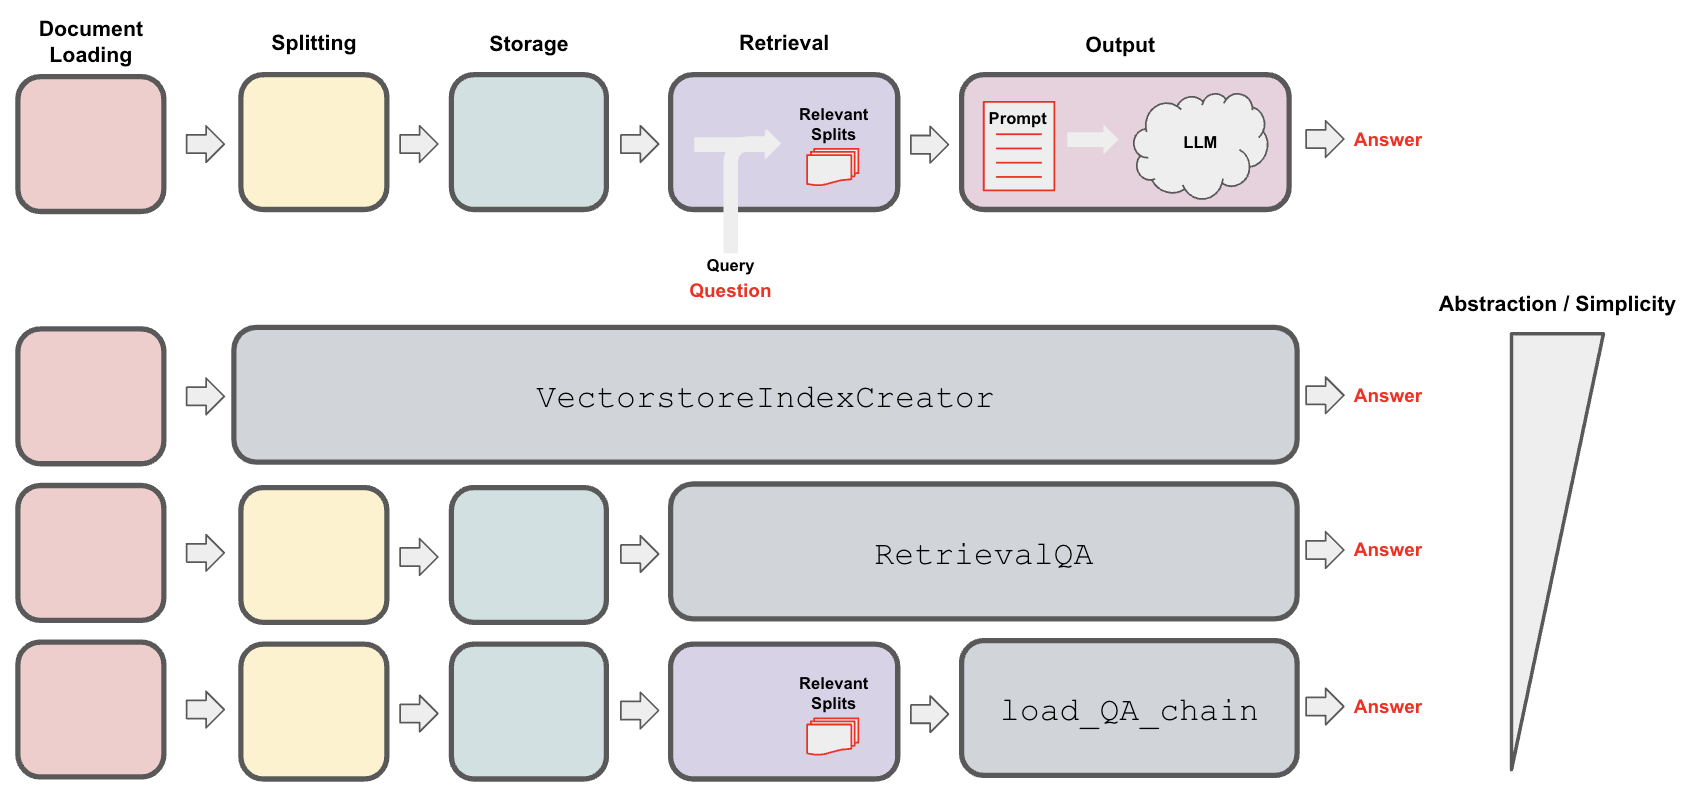

In [ ]:
from langchain.chains import RetrievalQA
qa_chain = RetrievalQA.from_chain_type(
    llm,
    retriever=docsearch.as_retriever(search_kwargs={"k": 3}),
    chain_type="stuff",
)
result = qa_chain({"query": query})

In [ ]:
result

{'query': 'What tools do full-stack data scientists need?',
 'result': ' According to the post, full-stack data scientists are expected to know lower-level infrastructure tools such as Kubernetes (K8s) and resource management. Additionally, the Twitter thread mentions tools like version control, SQL, Python, Pandas/Dask, data structures, probability and statistics, ML algorithms, parallel computing, REST API, and unit/integration tests.'}